In [ ]:
# imports — Keras til model og datahåndtering, sklearn til class weighting og confusion matrix
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import numpy as np
from glob import glob
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import itertools # confusion matrix-plottet
import tensorflow as tf
import os

In [ ]:
# mount google drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# udpak datasæt

import zipfile
import os

extraction_path = '/content/bd_plant_diseases.v1i.folder'
zip_file_path = '/content/drive/MyDrive/Colab Notebooks/Plant Disease Classifier/bd_plant_diseases.v1i.folder.zip'

if not os.path.exists(extraction_path):
    print(f"Udpakker {zip_file_path} til {extraction_path}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("Udpakning fuldført.")
else:
    print(f"Mappen '{extraction_path}' eksisterer allerede. Springer udpakning over.")

Mappen '/content/bd_plant_diseases.v1i.folder' eksisterer allerede. Springer udpakning over.


In [ ]:
# konstanter og stier
IMAGE_SIZE = [100, 100]
epochs = 20
batch_size = 50

train_path = '/content/bd_plant_diseases.v1i.folder/train'
valid_path = '/content/bd_plant_diseases.v1i.folder/valid'
test_path = '/content/bd_plant_diseases.v1i.folder/test'

Selected image path: /content/bd_plant_diseases.v1i.folder/train/Tomato_Bacterial_spot/image-1674-_JPG.rf.44941c12a1bef2755f1e1bcdc7c1e457.jpg


35

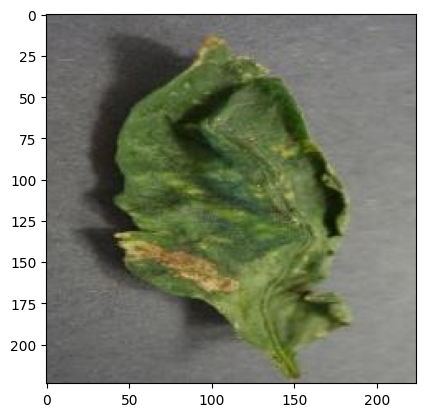

In [ ]:
# glob + preview

image_files = glob(train_path + '/*/*.jp*g')
folders = glob(train_path + '/*')

chosen_image_path = np.random.choice(image_files)
print(f"Selected image path: {chosen_image_path}")
plt.imshow(image.load_img(chosen_image_path))
len(folders)

In [ ]:
# ResNet50 pretrænet på ImageNet med frosne lag — kun custom head trænes (35 output-klasser)

resNet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

for layer in resNet.layers:
      layer.trainable = False

layers = Flatten()(resNet.output)
layers = Dense(30, activation='relu')(layers)
layers = Dropout(0.2)(layers)
layers = Dense(30, activation='relu')(layers)
layers = Dense(len(folders), activation='softmax')(layers)

model = Model(inputs=resNet.input, outputs=layers)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 106, 106,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 50, 50,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 50, 50,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 50, 50,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 52, 52,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 25, 25,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 25, 25,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 25, 25,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 25, 25,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 25, 25,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 25, 25,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 25, 25,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 25, 25,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 25, 25,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 25, 25,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 25, 25,    │      1,024 │ conv2_block1_3_c

 Total params: 24,572,797 (93.74 MB)

 Trainable params: 985,085 (3.76 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# lr=0.0001 frem for standard 0.001 — lavere rate giver stabilitet med aggressive class weights
model.compile(
      loss='sparse_categorical_crossentropy',
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
      metrics=['accuracy']
  )

In [ ]:
# augmentering kun på train — valid og test må ikke augmenteres da de skal repræsentere virkeligheden præcist
train_datagen = ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True,
    vertical_flip = True,
    preprocessing_function = preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

training_set = train_datagen.flow_from_directory(
    train_path,
    target_size = IMAGE_SIZE,
    shuffle = True,
    batch_size = batch_size,
    class_mode = 'sparse' # memory efficient, erstatter one-hot med tal fra 0-x
)

valid_set = valid_datagen.flow_from_directory(
    valid_path,
    target_size = IMAGE_SIZE,
    shuffle = False,
    batch_size = batch_size,
    class_mode = 'sparse'
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size = IMAGE_SIZE,
    shuffle = False,
    batch_size = batch_size,
    class_mode = 'sparse' # memory efficient, erstatter one-hot med tal fra 0-x
)

Found 21408 images belonging to 35 classes.
Found 6119 images belonging to 35 classes.
Found 3060 images belonging to 34 classes.


In [ ]:
# class weighting kompenserer for ubalancen (1:143 ratio) — Rice-klasser vægter op til 23x mere end Tomato_Yellow_Leaf_Curl_Virus
classes = np.array(sorted(training_set.class_indices.values()))
weights = compute_class_weight(class_weight='balanced', classes=classes,
y=training_set.classes)
class_weight_dict = dict(zip(classes, weights))

print(class_weight_dict)

{np.int64(0): np.float64(5.227838827838828), np.int64(1): np.float64(8.73795918367347), np.int64(2): np.float64(5.510424710424711), np.int64(3): np.float64(3.9977591036414566), np.int64(4): np.float64(1.7181380417335474), np.int64(5): np.float64(0.757001414427157), np.int64(6): np.float64(0.8566626650660264), np.int64(7): np.float64(0.7560656895638355), np.int64(8): np.float64(4.564605543710021), np.int64(9): np.float64(4.6337662337662335), np.int64(10): np.float64(4.307444668008048), np.int64(11): np.float64(4.337993920972645), np.int64(12): np.float64(4.307444668008048), np.int64(13): np.float64(4.530793650793651), np.int64(14): np.float64(4.050709555345317), np.int64(15): np.float64(0.8627040096715696), np.int64(16): np.float64(0.8968579807289485), np.int64(17): np.float64(5.996638655462185), np.int64(18): np.float64(18.535064935064934), np.int64(19): np.float64(23.525274725274727), np.int64(20): np.float64(1.6576074332171893), np.int64(21): np.float64(20.388571428571428), np.int64(

In [ ]:
# træning med validation på valid_set — test_set gemmes til endelig evaluering
history = model.fit(
    training_set,
    validation_data = valid_set,
    epochs = epochs,
    class_weight = class_weight_dict
)

Epoch 1/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 120s 247ms/step - accuracy: 0.2812 - loss: 2.7491 - val_accuracy: 0.5623 - val_loss: 1.6340
Epoch 2/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 90s 209ms/step - accuracy: 0.5058 - loss: 1.9849 - val_accuracy: 0.7189 - val_loss: 1.0251
Epoch 3/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 91s 211ms/step - accuracy: 0.5925 - loss: 1.5527 - val_accuracy: 0.7385 - val_loss: 0.8919
Epoch 4/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 93s 215ms/step - accuracy: 0.6341 - loss: 1.3319 - val_accuracy: 0.7929 - val_loss: 0.7263
Epoch 5/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 92s 215ms/step - accuracy: 0.6737 - loss: 1.1501 - val_accuracy: 0.8000 - val_loss: 0.6647
Epoch 6/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 94s 219ms/step - accuracy: 0.6945 - loss: 1.0675 - val_accuracy: 0.7854 - val_loss: 0.6957
Epoch 7/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 138s 211ms/step - accuracy: 0.7174 - loss: 0.9670 - val_accuracy: 0.8045 - val_loss: 0.6005
Epoch 8/20
429/429 ━━━━━━━━━━━━━━━━━━━━ 91s 212ms/step - accuracy: 0.7306 - loss:

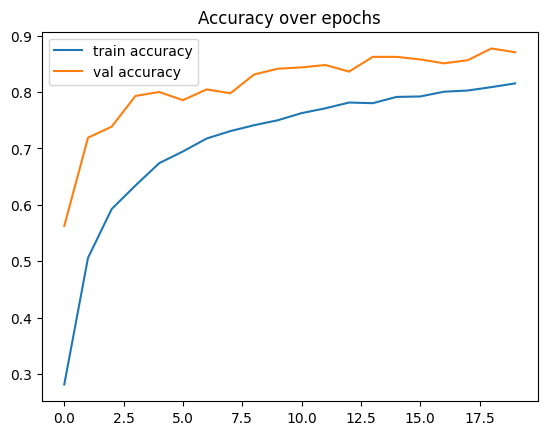

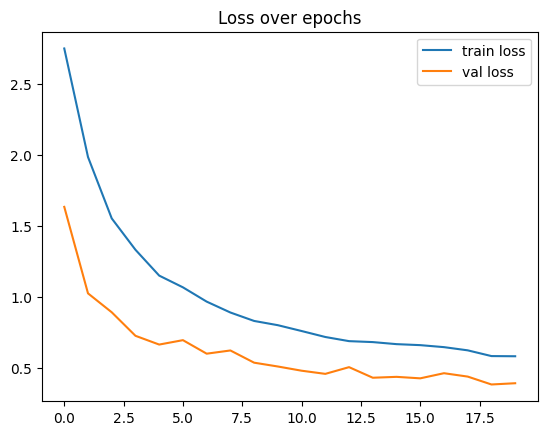

In [ ]:
# train accuracy < val accuracy er forventeligt — augmentering gør træningsbilleder sværere
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss over epochs')
plt.show()

In [ ]:
# OBS: test accuracy (24%) er misvisende — Rice_Bacterial_leaf_blight mangler i test og forskyder class indices fra 18 og frem
print(model.evaluate(test_set))

62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.2458 - loss: 7.8642
[7.864198684692383, 0.24575163424015045]


62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step


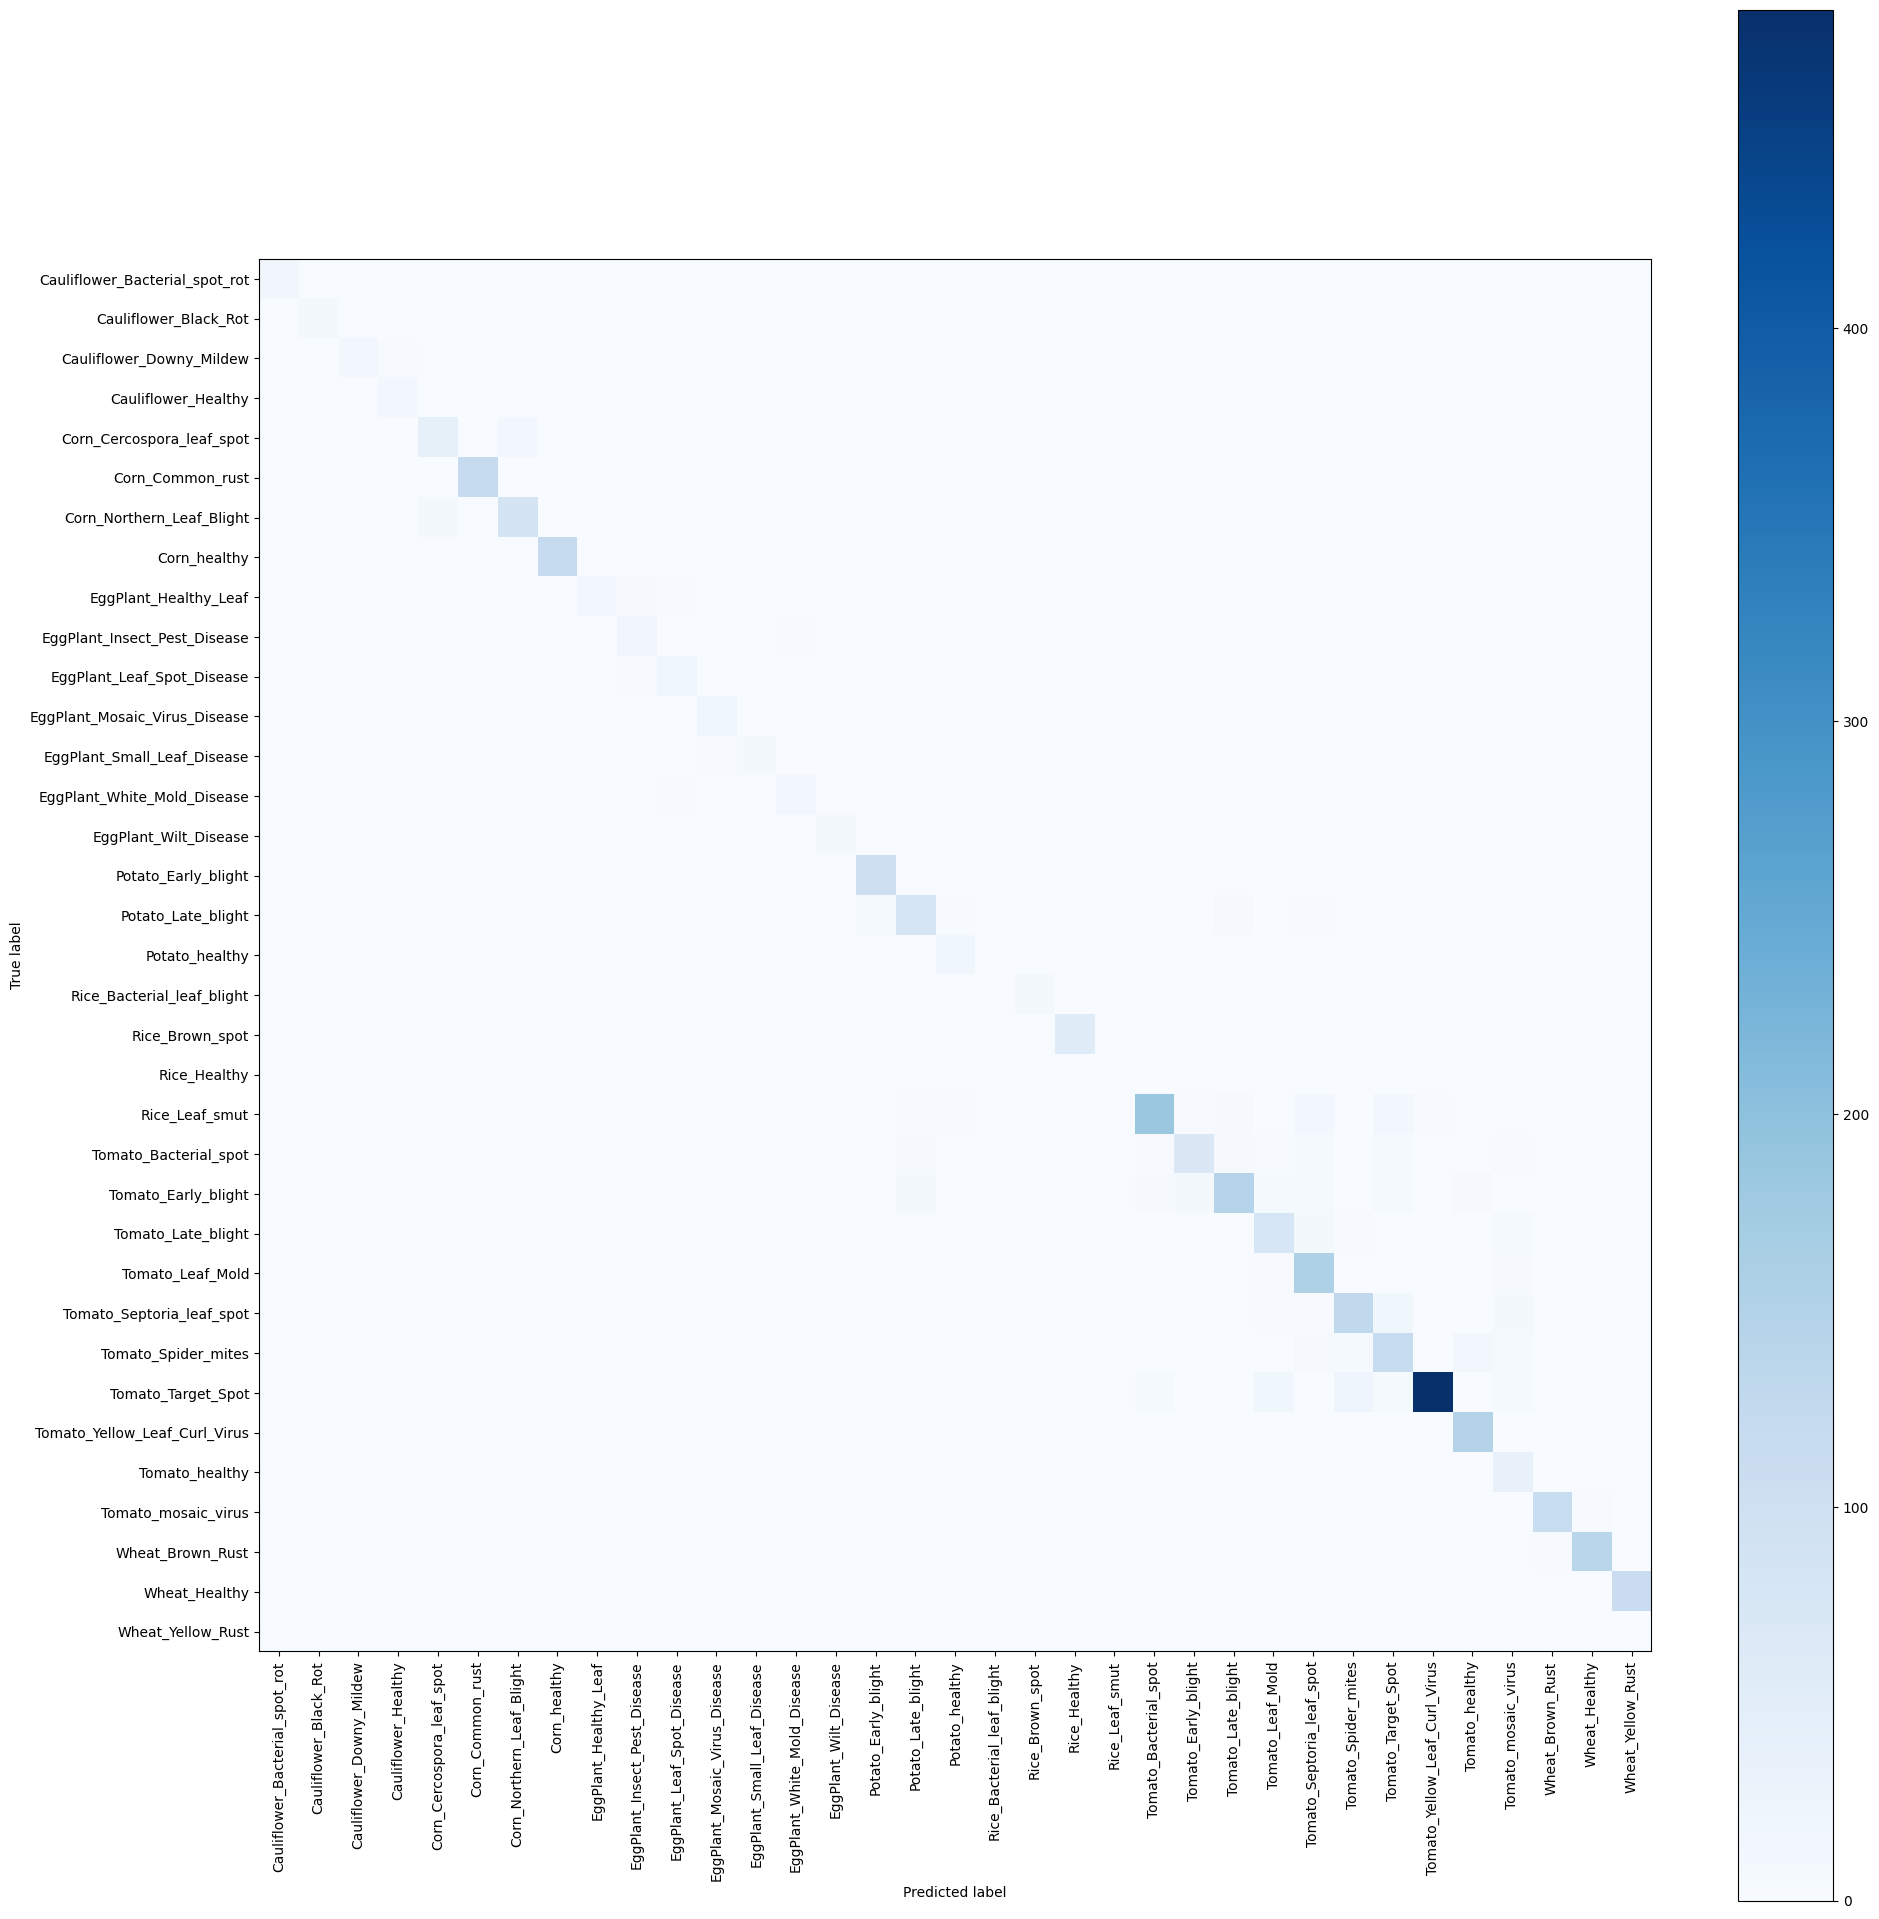

In [ ]:
 # Trin 1 — få forudsigelser:
predictions = model.predict(test_set)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_set.classes
class_labels = list(training_set.class_indices.keys())

# Trin 2 — beregn matrix:
cm = confusion_matrix(true_classes, predicted_classes)

# Trin 3 — plot:
plt.figure(figsize=(20, 20))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=90)
plt.yticks(tick_marks, class_labels)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

/content/bd_plant_diseases.v1i.folder/valid/Potato_Early_blight/image-287-_JPG.rf.0e91f2f1f8639f829fbd6b6b5f47ded9.jpg


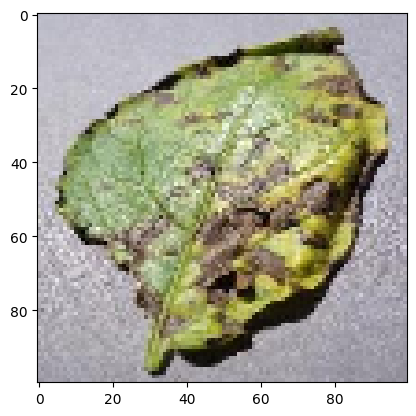

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Forudsagt: Potato_Early_blight
Sand klasse: Potato_Early_blight


In [ ]:
# enkelt-prediktion på tilfældigt billede fra valid_set
valid_files = glob(valid_path + '/*/*.jp*g')
single_pred = np.random.choice(valid_files)

print(single_pred)

test_image = image.load_img(single_pred, target_size=IMAGE_SIZE, color_mode='rgb')
plt.imshow(test_image)
plt.show()

test_image = image.img_to_array(test_image)
test_image = preprocess_input(test_image)
test_image = np.expand_dims(test_image, axis=0)

result = model.predict(test_image)
predicted_class = np.argmax(result[0])
class_labels = list(training_set.class_indices.keys())
print("Forudsagt:", class_labels[predicted_class])

true_label = os.path.basename(os.path.dirname(single_pred))
print("Sand klasse:", true_label)

In [ ]:
# gem model til genbrug uden at skulle retræne
model.save('plant_disease_model.keras')